# VoC and Customer Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

### a. Load the dataset

Google Play Review Dataset

In [2]:
# read google play review data -> save dataframe to rev_df

rev_df = pd.read_csv('../data/raw/Google Play Reviews/reviews.csv')

Let's get a sense of the structure of our data..

### b. Data Exploration

- Explore columns
- Fix datatypes
- Check counts, etc.

#### i. Column and Types

In [4]:
# 1. check the shape of the data
rev_df.shape

print(f'There are {rev_df.shape[0]} rows of data, and {rev_df.shape[1]} columns')

There are 12495 rows of data, and 12 columns


In [9]:
rev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12495 entries, 0 to 12494
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              12495 non-null  object
 1   userName              12495 non-null  object
 2   userImage             12495 non-null  object
 3   content               12495 non-null  object
 4   score                 12495 non-null  int64 
 5   thumbsUpCount         12495 non-null  int64 
 6   reviewCreatedVersion  10333 non-null  object
 7   at                    12495 non-null  object
 8   replyContent          5818 non-null   object
 9   repliedAt             5818 non-null   object
 10  sortOrder             12495 non-null  object
 11  appId                 12495 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.1+ MB


df.info() provides a summary of how the data looks like...

We can see the datatypes, counts of non-null values etc.

In [11]:
# check for missing values

print(rev_df.isna().sum())

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    2162
at                         0
replyContent            6677
repliedAt               6677
sortOrder                  0
appId                      0
dtype: int64


In [8]:
# check for duplicates

print(f'Total number of duplicates in the dataset: {rev_df.duplicated().sum()}')

Total number of duplicates in the dataset: 0


### Explore Columns

In [12]:
# explore 'score' column
print('These are the unique values in "score" column', rev_df['score'].unique())

print('The datatype of this column is ', rev_df['score'].dtype)

These are the unique values in "score" column [1 2 3 4 5]
The datatype of this column is  int64


In [13]:
# explore 'at' column
print('The datatype of this column is', rev_df['at'].dtype)

The datatype of this column is object


In [14]:
# convert datetime data type

rev_df['at'] = pd.to_datetime(rev_df['at'], errors='coerce')
print('The datatype of this column is', rev_df['at'].dtype)

The datatype of this column is datetime64[ns]


In [17]:
# explore 'repliedAt' column

print('These datatype of repliedAt column', rev_df['repliedAt'].dtype)

These datatype of repliedAt column datetime64[ns]


In [18]:
# change repliedAt dtype to datetime

rev_df['repliedAt'] = pd.to_datetime(rev_df['repliedAt'], errors='coerce')
print('The datatype of the repliedAt column', rev_df['repliedAt'].dtype)

The datatype of the repliedAt column datetime64[ns]


In [19]:
# explore 'sortOrder' and 'appId' columns
print('Datatype for sortOrder is', rev_df['sortOrder'].dtype)

print('Datatype for appId is', rev_df['appId'].dtype)

Datatype for sortOrder is object
Datatype for appId is object


In [20]:
print('Total values in sortOrder:', len(rev_df['sortOrder'].unique()))
print('\nTotal values in appId:', len(rev_df['appId'].unique()))


Total values in sortOrder: 1

Total values in appId: 15


In [21]:
# convert these datatypes to category.

rev_df['sortOrder'] = rev_df['sortOrder'].astype('category')

rev_df['appId'] = rev_df['appId'].astype('category')

In [34]:
# drop columns 

rev_df = rev_df.drop(columns=['userImage'])

In [36]:
rev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12495 entries, 0 to 12494
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              12495 non-null  object        
 1   userName              12495 non-null  object        
 2   content               12495 non-null  object        
 3   score                 12495 non-null  int64         
 4   thumbsUpCount         12495 non-null  int64         
 5   reviewCreatedVersion  10333 non-null  object        
 6   at                    12495 non-null  datetime64[ns]
 7   replyContent          5818 non-null   object        
 8   repliedAt             5818 non-null   datetime64[ns]
 9   sortOrder             12495 non-null  category      
 10  appId                 12495 non-null  category      
dtypes: category(2), datetime64[ns](2), int64(2), object(5)
memory usage: 903.9+ KB


For majority of the dataset, there are no nulls. But there are 3 columns with null values:
- reviewCreatedVersion
- replyContent
- repliedAt


### Language Check (if texts exist)

In [37]:
from langdetect import detect, LangDetectException

In [38]:
def detect_language(text):
    try:
        if not isinstance(text, str):
            return 'not a string'
        return detect(text)
    except LangDetectException:
        return 'unknown'

In [39]:
# create a new feature -> detected_lang for extracted language of review content

rev_df['detected_lang'] = rev_df['content'].apply(detect_language)

In [41]:
print(f"There are {len(rev_df['detected_lang'].unique())} values")

There are 45 values


In [42]:
rev_df['detected_lang'] = rev_df['detected_lang'].astype('category')

In [43]:
print(f"There are {len(rev_df['replyContent'].apply(detect_language).unique())} values")

rev_df['replyContent'] = rev_df['replyContent'].astype('category')

There are 24 values


In [79]:
# Quick language detection (sample 20 rows)
from langdetect import detect

sample_texts = rev_df['content'].dropna().sample(20, random_state=42)
for t in sample_texts:
    try:
        print(detect(str(t)), ":", t[:80])
    except:
        print("could not detect:", t[:80])

en : It's very easy to add tasks with its incredible Natural Language Processing.
en : Absolutely useless, worked once then never again. Am now living in amonst my hou
en : I bought premium and now I can't login to the app using Facebook. (and I can't l
en : Yo, fix the widget
en : Useless app... Niether Reminder nor notifications ping... Wasted too much time o
en : This app is Very Awesome, always keeps me on track 100%✓
af : Didn't feel like a game
en : Great habit tracker
en : I love the variety of settings and options
en : Very useful but completely loses it's value when you don't get notifications of 
en : Great app! It helped me get my life together.
en : Very easy to use. I have not experienced any problems with this app.
en : A best app for students who cannot focus on there study /work
en : Loved this app but I prefer writing things down
en : Doesnt show you task in outlook calendar Planned task aren't shown in My day whe
ne : फर्जी
so : Good
en : So far I love it. Clear and s

### Text Sanity Checks

* Tokenization
* Lemminization etc

In [45]:
# get the length of the review content
rev_df['char_len'] = rev_df['content'].astype(str).apply(len)

# tokenize the review content
rev_df['token_len'] = rev_df['content'].astype(str).apply(lambda x: len(x.split()))

# describe these newly engineered columns
rev_df[['char_len','token_len']].describe()

,char_len,token_len
count,12495.000000,12495.000000
mean,147.756543,27.675710
std,152.584356,28.381852
min,1.000000,1.000000
25%,37.000000,7.000000
50%,97.000000,18.000000
75%,211.000000,40.000000
max,4076.000000,723.000000


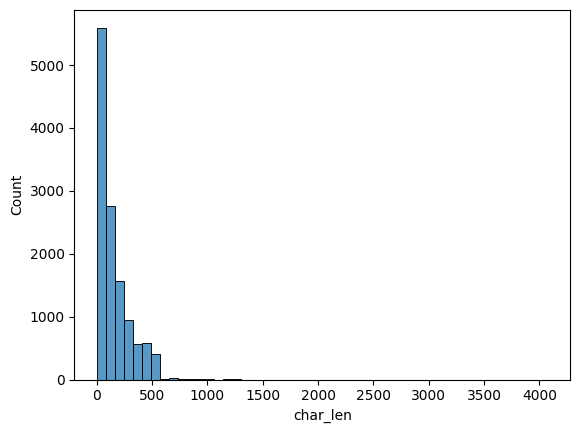

In [47]:
# plot the distribution from character analysis

sns.histplot(rev_df['char_len'], bins=50)
plt.show()


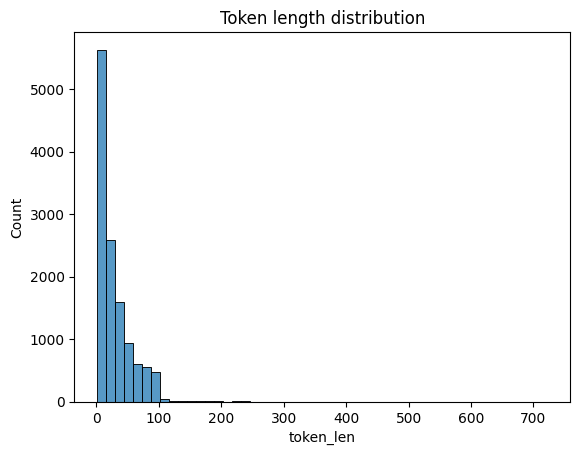

In [82]:
# plot distribution from tokenization

sns.histplot(rev_df['token_len'], bins=50)
plt.title("Token length distribution")
plt.show()

In [80]:
# percentages of reviews that are blank

empty_pct = (rev_df['char_len'] == 0).mean()
short_pct = (rev_df['token_len'] <= 3).mean()

print(f"There percentage of empty reviews are {empty_pct * 100} \nThe percentage of tokens less than or equal to 3 is {short_pct*100:.2f}")


There percentage of empty reviews are 0.0 
The percentage of tokens less than or equal to 3 is 13.95


### Sentiment Analysis

In [59]:
# create a function to map sentiments

def map_sentiment(star):
    if star in [1,2]:
        return "negative"
    elif star == 3:
        return "neutral"
    elif star in [4,5]:
        return "positive"

In [63]:
# create a new feature 'sentiment_proxy' based on score ratings

rev_df['sentiment_proxy'] = rev_df['score'].apply(map_sentiment)

print(rev_df['sentiment_proxy'].value_counts(normalize=True))


sentiment_proxy
positive    0.452501
negative    0.388155
neutral     0.159344
Name: proportion, dtype: float64


### Net Promoter Score (NPS) analysis

In [64]:
# create a function to map different sentiments to nps metrics
def nps_label(score):
    if score == "negative": return "Detractor"
    elif score == "neutral": return "Passive"
    else: return "Promoter"

In [68]:
# create new feature 'nps_label'

rev_df['nps_label'] = rev_df['sentiment_proxy'].apply(nps_label)

promoters = (rev_df['nps_label'] == "Promoter").mean()
detractors = (rev_df['nps_label'] == "Detractor").mean()
nps = (promoters - detractors) * 100

print(f"nps is {nps:.2f}")

nps is 6.43


In [70]:
# extract frequent unigrams/bigrams
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=20)

X = vect.fit_transform(rev_df['content'].astype(str))

Counter(dict(zip(vect.get_feature_names_out(), X.sum(axis=0).A1)))

Counter({'app': np.int64(7693),
         'good': np.int64(1744),
         'like': np.int64(1734),
         'use': np.int64(1615),
         'time': np.int64(1562),
         'tasks': np.int64(1520),
         'great': np.int64(1488),
         'just': np.int64(1329),
         'calendar': np.int64(1211),
         'really': np.int64(1209),
         'task': np.int64(1149),
         'love': np.int64(1123),
         'day': np.int64(1029),
         'version': np.int64(1014),
         'work': np.int64(970),
         'don': np.int64(919),
         'list': np.int64(900),
         'add': np.int64(786),
         'premium': np.int64(763),
         'need': np.int64(723)})

### KPI analysis

In [77]:
# create a kpi dictionary

kpis = {
    "rows":rev_df.shape[0],
    "cols": rev_df.shape[1],
    "missing_text_pct": rev_df['content'].isna().mean(),
    "duplicates": rev_df.duplicated().sum(),
    "avg_char_len": rev_df['char_len'].mean(),
    "avg_token_len": rev_df['token_len'].mean(),
    "empty_pct": empty_pct,
    "short_pct": short_pct,
    "sentiment_dist": rev_df['sentiment_proxy'].value_counts(normalize=True).to_dict()
}


In [78]:
kpis

{'rows': 12495,
 'cols': 16,
 'missing_text_pct': np.float64(0.0),
 'duplicates': np.int64(0),
 'avg_char_len': np.float64(147.75654261704682),
 'avg_token_len': np.float64(27.675710284113645),
 'empty_pct': np.float64(0.0),
 'short_pct': np.float64(0.13949579831932774),
 'sentiment_dist': {'positive': 0.45250100040016006,
  'negative': 0.3881552621048419,
  'neutral': 0.159343737494998}}

In [84]:
# Save processed file

rev_df.to_csv("../data/processed/processed_reviews.csv", index=False)